In [2]:
# Analysen zum Datenbestand der Kundenrezensionen von Trustpilot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, f_oneway

#BASE_CLEAN = "../data/clean/"
#os.makedirs(BASE_CLEAN, exist_ok=True)

# Laden des Datensatzes
df = pd.read_csv("../data/clean/reviews_clean_test.csv")
df.head()

#df['date'] = pd.to_datetime(df['date'])
df.columns
df.isnull().sum()
df.dropna().head(15)


FileNotFoundError: [Errno 2] No such file or directory: '../data/clean/reviews_clean_test.csv'

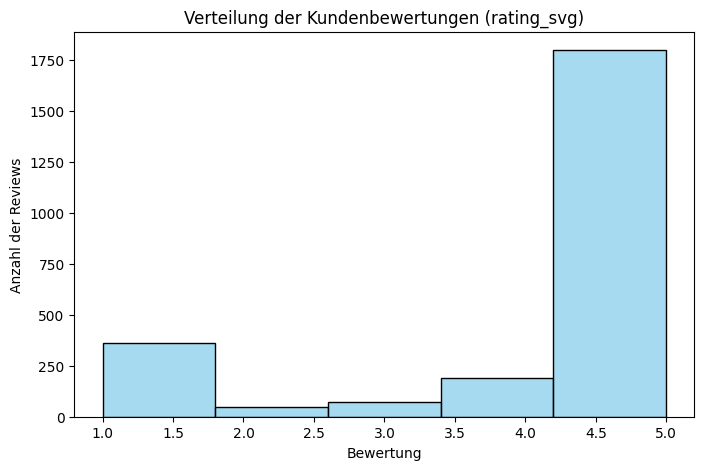

Mittelwert: 4.22, Median: 5.00


In [4]:

# ---- 1. Histogramm der Ratings ----
plt.figure(figsize=(8,5))
sns.histplot(df['rating_svg'], bins=5, kde=False, color='skyblue')
plt.title("Verteilung der Kundenbewertungen (rating_svg)")
plt.xlabel("Bewertung")
plt.ylabel("Anzahl der Reviews")
plt.show()

# Business-Kommentar:
# Die meisten Bewertungen liegen im Bereich 4-5 Sterne, was auf eine grundsätzlich hohe Kundenzufriedenheit hinweist.
# Es gibt jedoch auch eine kleine Anzahl sehr schlechter Bewertungen.

# Validierung
mean_rating = df['rating_svg'].mean()
median_rating = df['rating_svg'].median()
print(f"Mittelwert: {mean_rating:.2f}, Median: {median_rating:.2f}")


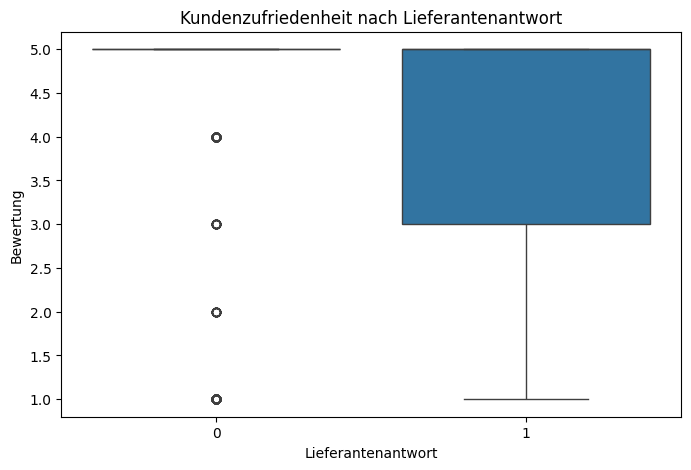

T-Test: t=-10.53, p=0.0000


supplier_response
False    1322
True     1151
Name: count, dtype: int64

In [ ]:
df['has_response'] = df['supplier_response'].notna().astype(int)
# ---- 2. Boxplot: Supplier Response vs. Rating ----
plt.figure(figsize=(8,5))
sns.boxplot(x='has_response', y='rating_svg', data=df)
plt.title("Kundenzufriedenheit nach Lieferantenantwort")
plt.xlabel("Lieferantenantwort")
plt.ylabel("Bewertung")
plt.show()

# Business-Kommentar:
# Kunden, die eine Antwort vom Lieferanten erhalten haben, zeigen tendenziell höhere Bewertungen.
# Dies deutet darauf hin, dass Kommunikation die Zufriedenheit positiv beeinflusst.

# Validierung mit T-Test
response_yes = df[df['has_response']==1]['rating_svg']
response_no = df[df['has_response']==0]['rating_svg']
t_stat, p_val = ttest_ind(response_yes, response_no, equal_var=False)
print(f"T-Test: t={t_stat:.2f}, p={p_val:.4f}")
#p < 0.05 → signifikanter Einfluss der Lieferantenantwort auf die Bewertung. 
# Die andere Frage ist, ob nur auf gute Bewertungen geantwortet wird
# oder vebessert eine Antwort auf einen schlechten Kommentar die Bewertung.
df['supplier_response'].notna().value_counts()
#df['has_response'].value_counts()


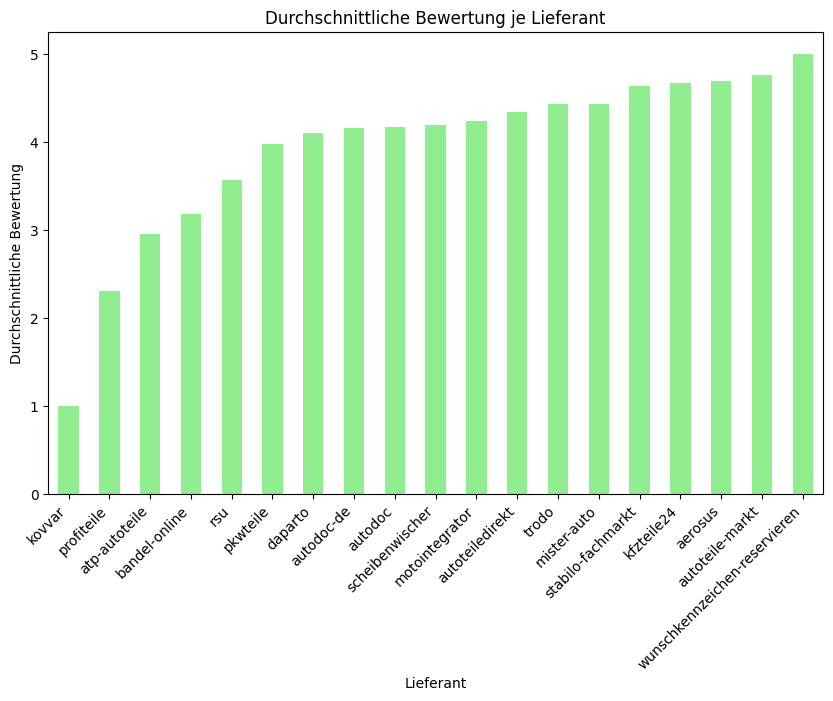

ANOVA: F=12.67, p=0.0000


In [12]:
# ---- 3. Balkendiagramm: Durchschnittsratings pro Lieferant ----
avg_rating_company = df.groupby('company')['rating_svg'].mean().sort_values()
plt.figure(figsize=(10,6))
avg_rating_company.plot(kind='bar', color='lightgreen')
plt.title("Durchschnittliche Bewertung je Lieferant")
plt.ylabel("Durchschnittliche Bewertung")
plt.xlabel("Lieferant")
plt.xticks(rotation=45, ha='right')
plt.show()

# Business-Kommentar:
# Einige Lieferanten schneiden deutlich besser ab als andere.
# Low-Performer sollten für Prozessoptimierungen genauer untersucht werden.

# Validierung mit ANOVA
company_groups = [group['rating_svg'].values for name, group in df.groupby('company')]
f_stat, p_val_anova = f_oneway(*company_groups)
print(f"ANOVA: F={f_stat:.2f}, p={p_val_anova:.4f}")



In [1]:
# ---- 4. Heatmap: Durchschnittsratings nach Standort ----
avg_rating_location = df.pivot_table(values='rating_svg', index='location', aggfunc='mean').sort_values('rating_svg', ascending=False)


plt.figure(figsize=(12,6))
sns.heatmap(avg_rating_location, annot=True, cmap="YlGnBu", cbar_kws={'label': 'Durchschnittliche Bewertung'})
plt.title("Durchschnittliche Bewertungen nach Standort")
plt.show()

# Business-Kommentar:
# Bestimmte Standorte haben systematisch niedrigere Bewertungen.
# Dies könnte auf regionale Lieferkettenprobleme oder logistische Herausforderungen hindeuten.



NameError: name 'df' is not defined

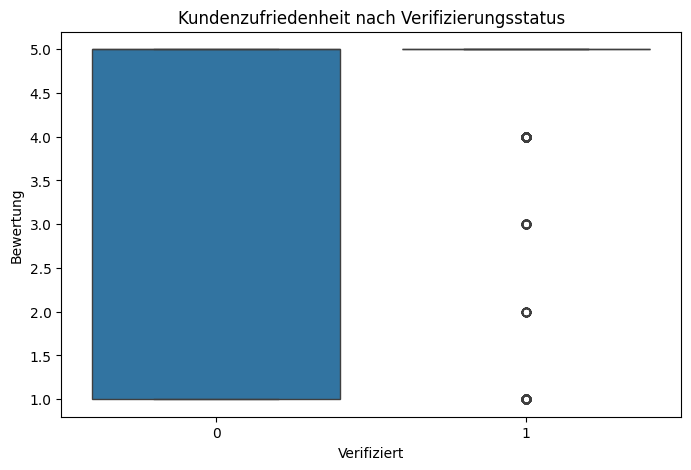

T-Test für Verified: t=15.63, p=0.0000


verified
0    3.462725
1    4.564602
Name: rating_svg, dtype: float64

In [ ]:
# ---- 5. Boxplot: Verified vs Rating ----
plt.figure(figsize=(8,5))
sns.boxplot(x='verified', y='rating_svg', data=df)
plt.title("Kundenzufriedenheit nach Verifizierungsstatus")
plt.xlabel("Verifiziert")
plt.ylabel("Bewertung")
plt.show()

# Hypothese:
# Verifizierte Bewertungen zeigen tendenziell höhere oder stabilere Bewertungen.
# Dies kann auf authentischere Feedback von echten Kunden hinweisen.

# Validierung mit T-Test
verified_yes = df[df['verified']==True]['rating_svg']
verified_no = df[df['verified']==False]['rating_svg']
t_stat_verified, p_val_verified = ttest_ind(verified_yes, verified_no, equal_var=False)
print(f"T-Test für Verified: t={t_stat_verified:.2f}, p={p_val_verified:.4f}")
#-> signifikant
# The inclusion of a ‘verified’ indicator allows us to distinguish 
# between authenticated and non-authenticated customer feedback, 
# reducing potential bias and increasing the reliability of the analysis.

df.groupby('verified')['rating_svg'].mean()

C:\Users\Olga\AppData\Local\Temp\ipykernel_30268\3823844399.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_avg = df.groupby(df['date'].dt.to_period('M'))['rating_svg'].mean()


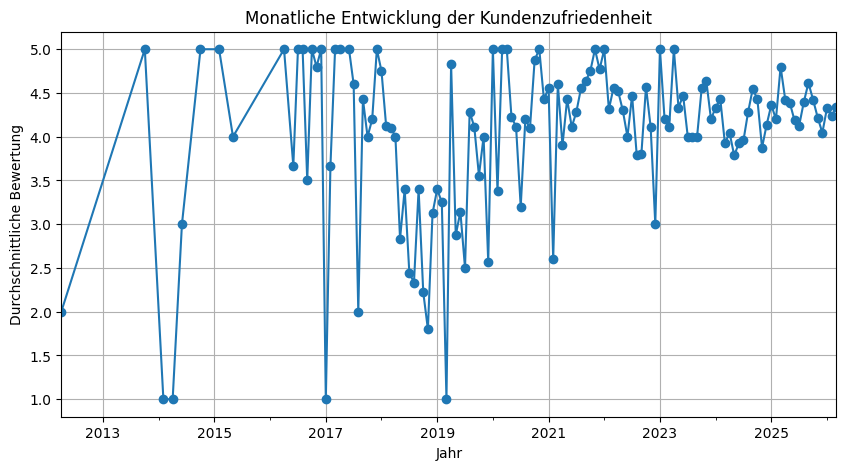

In [18]:

df["date"] = pd.to_datetime(df["date"], errors='coerce')
#---  Zeitliche Entwicklung der Bewertungen ----
monthly_avg = df.groupby(df['date'].dt.to_period('M'))['rating_svg'].mean()
plt.figure(figsize=(10,5))
monthly_avg.plot(marker='o')
plt.title("Monatliche Entwicklung der Kundenzufriedenheit")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche Bewertung")
plt.grid(True)
plt.show()

# Business-Kommentar:
# Ab 2017 lassen sich zeitliche Schwankungen erkennen, z. B. Peaks oder Einbrüche.
# Diese könnten mit neuen Produkteinführungen oder Lieferproblemen korrelieren.

['autodoc' 'car' 'company' 'customer' 'day' 'delivery' 'fast' 'good'
 'great' 'item' 'one' 'order' 'ordered' 'part' 'price' 'product' 'quality'
 'reply' 'service' 'time']


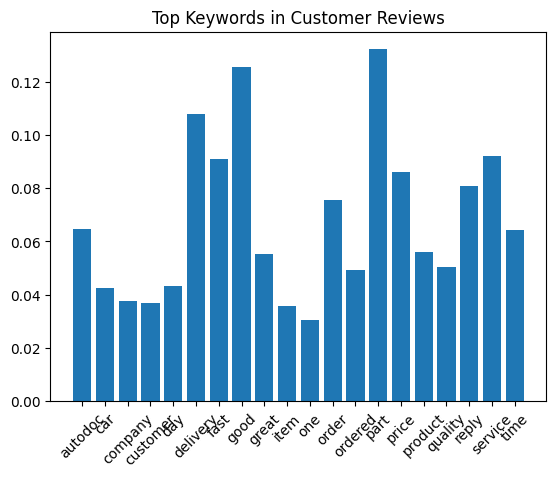

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=20)
X = vectorizer.fit_transform(df['review_text_clean_advanced'].fillna(''))

keywords = vectorizer.get_feature_names_out()

print(keywords)

import matplotlib.pyplot as plt
import numpy as np

scores = X.mean(axis=0).A1

plt.bar(keywords, scores)
plt.xticks(rotation=45)
plt.title("Top Keywords in Customer Reviews")
plt.show()


Text(0.5, 1.0, 'Anzahl der Probleme pro Bewertung')

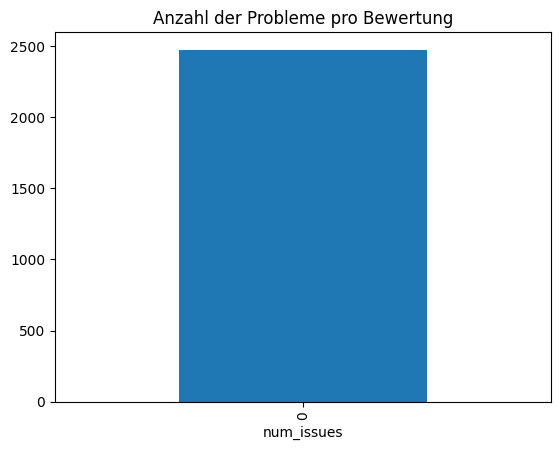

In [ ]:
#
# df['num_issues'] = df['issue_categories'].apply(lambda x: len(x) if isinstance(x, list) else 0)

#df['issue_categories'].value_counts().plot(kind='bar')
#plt.title("Distribution of Supply Chain Issues")
#plt.show()